#### UAV Autonomy Summer Camp 2026: Abto Software

---

# <center> Домашнє завдання №2 <center>

#### виконав Горбатюк Данило

<br>

> Маючи вхідне зображення гри, намальованої на папері, необхідно його проаналізувати та визначити стан ігрового поля. Створіть власне зображення гри (радимо скористатися чорним маркером), використавши іншу комбінацію хрестиків та нуликів, ніж у прикладі.

> Необхідно: <br>
    1. Реалізувати розпізнавання сітки ігрового поля, а також усіх клітинок сітки та символів у них.<br>
    2. Відобразити результати розпізнавання на вихідному зображенні (виділити сітку та символи).<br>
    3. Якщо на полі є виграшна комбінація (три однакові символи поспіль по горизонталі, вертикалі або діагоналі), провести через неї пряму лінію.

<br>

Було взято власне зображення (4 комбінації: ніхто не виграв, виграли нулики, виграли хрестики, і дуже погані контури: незамкнені, криві фігури, зазори) і розбито на 4 мені зображення.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

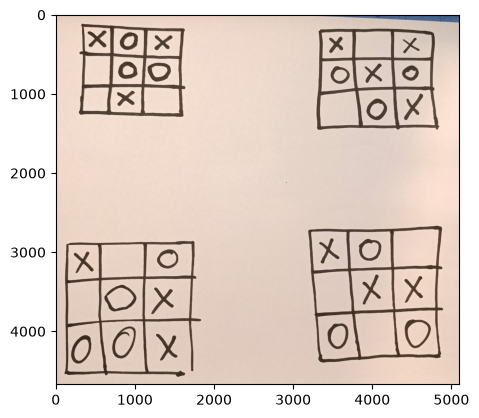

In [3]:
full_field_90 = cv2.imread("input/full_field_90.jpg")
plt.imshow(full_field_90)

<i> Зображення ігрових полів на одному аркуші, фото зроблено перпендикулярно до аркуша паперу </i>

In [4]:
def plot_images_in_row(images, titles=None, figsize=(15, 5)):
    number_images = len(images)
    fig, axes = plt.subplots(1, number_images, figsize=figsize)
    if number_images == 1:
        axes = [axes]
    for i in range(number_images):
        axes[i].imshow(images[i])
        if titles is not None and i < len(titles):
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.rcParams.update(plt.rcParamsDefault)
    plt.tight_layout()
    plt.show()

In [110]:
bad_photo_and_circles_wins = cv2.imread("input/cases/bad_photo_and_circles_wins.jpg", cv2.IMREAD_COLOR_RGB)
crosses_wins = cv2.imread("input/cases/crosses_wins.jpg", cv2.IMREAD_COLOR_RGB)
nobody_wins = cv2.imread("input/cases/nobody_wins.jpg", cv2.IMREAD_COLOR_RGB)
nobody_wins_2 = cv2.imread("input/cases/nobody_wins_2.jpg", cv2.IMREAD_COLOR_RGB)

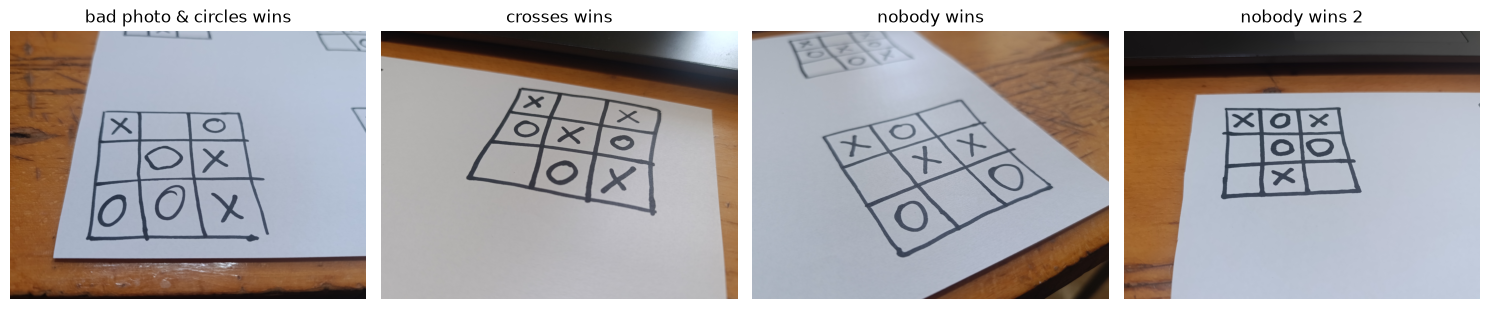

In [111]:
plot_images_in_row([bad_photo_and_circles_wins,
                    crosses_wins,
                    nobody_wins,
                    nobody_wins_2],
                   [
                       "bad photo & circles wins",
                       "crosses wins",
                       "nobody wins",
                       "nobody wins 2",
                   ])

In [112]:
images = {
    "bad photo & circles wins": bad_photo_and_circles_wins,
    "crosses wins": crosses_wins,
    "nobody wins": nobody_wins,
    "nobody wins 2": nobody_wins_2,
}

## Попередня обробка зображення

Використаємо Отсу, щоб знайти маски паперу на якому зображена сітка


In [113]:
image_and_masks = {}

for name, image in images.items():
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3,3), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((21, 21), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    image_and_masks.update({name: mask})
    # result = cv2.bitwise_and(image, image, mask=mask)


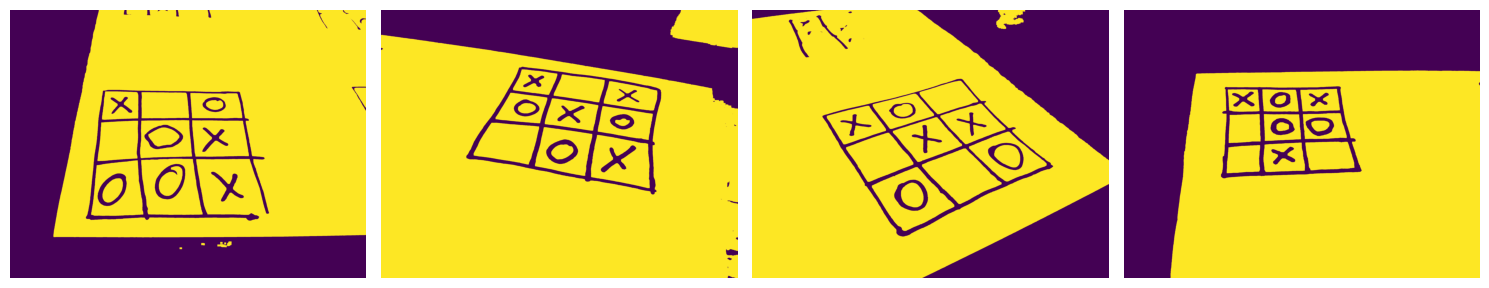

In [114]:
plot_images_in_row(
    list(image_and_masks.values())
)

In [115]:
def keep_largest_foreground(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    # label 0 - завжди фон (там де mask == 0), пропускаємо
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_label = 1 + np.argmax(areas)

    cleaned = np.where(labels == largest_label, 255, 0).astype(np.uint8)
    return cleaned

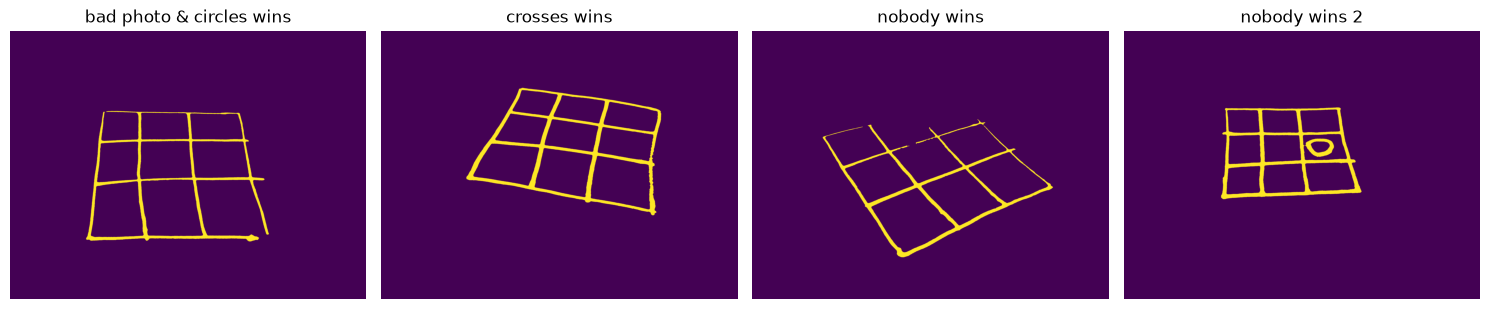

In [182]:
clean_masks = {name: keep_largest_foreground(mask) for name, mask in grid_masks.items()}

plot_images_in_row(list(clean_masks.values()), list(clean_masks.keys()))

In [183]:
grid_contours = {}

for name, mask in clean_masks.items():
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    grid_contours[name] = max(contours, key=cv2.contourArea)

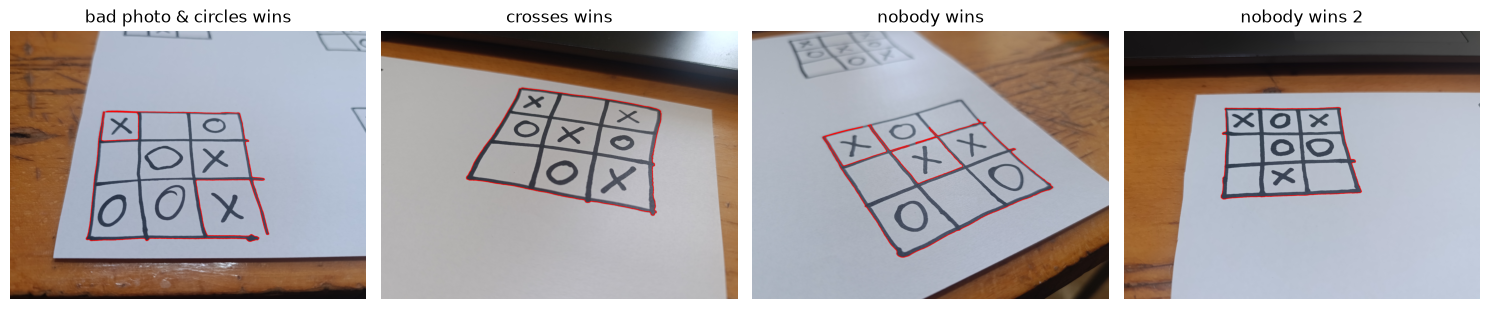

In [184]:
contour_previews = []

for name in images:
    canvas = images[name].copy()
    cv2.drawContours(canvas, [grid_contours[name]], -1, (255, 0, 0), 8)
    contour_previews.append(canvas)

plot_images_in_row(contour_previews, list(images.keys()))

In [185]:
def order_points(pts):
    pts = pts.reshape(4, 2).astype(np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()

    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = pts[np.argmin(s)]      # top-left
    ordered[2] = pts[np.argmax(s)]      # bottom-right
    ordered[1] = pts[np.argmin(diff)]   # top-right
    ordered[3] = pts[np.argmax(diff)]   # bottom-left
    return ordered


def get_corners(contour):
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)

    use_min_area_rect = len(approx) != 4
    if not use_min_area_rect:
        contour_area = cv2.contourArea(contour)
        if contour_area == 0 or abs(cv2.contourArea(approx) - contour_area) / contour_area > 0.15:
            use_min_area_rect = True

    if use_min_area_rect:
        rect = cv2.minAreaRect(contour)
        approx = cv2.boxPoints(rect).astype(np.float32).reshape(-1, 1, 2)

    return order_points(approx)


def warp_to_square(img, contour, size=600):
    src = get_corners(contour)
    dst = np.array([[0, 0], [size - 1, 0], [size - 1, size - 1], [0, size - 1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (size, size))

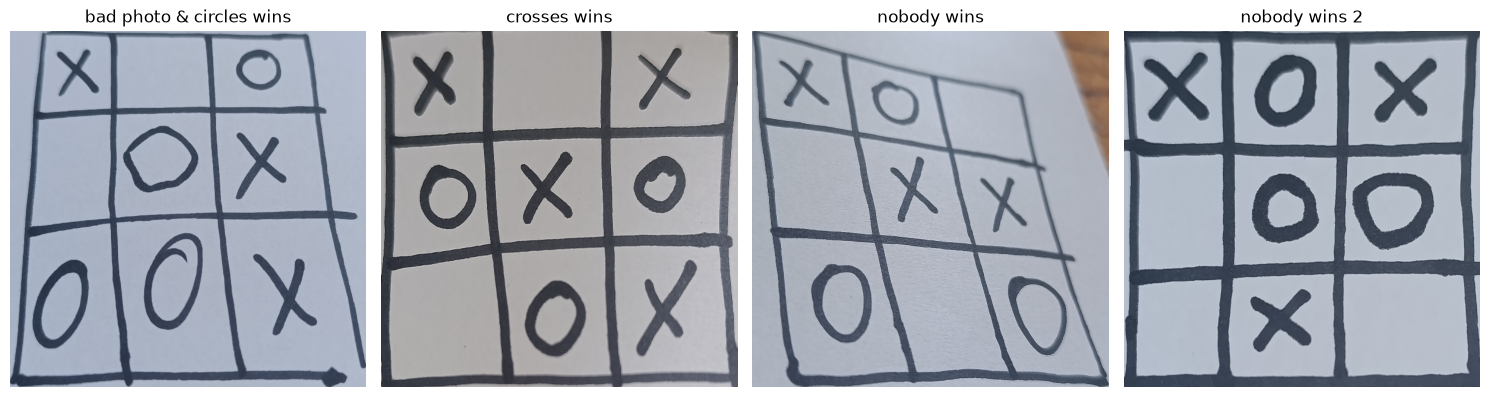

In [186]:
warped_grids = {
    name: warp_to_square(images[name], grid_contours[name], size=600)
    for name in images
}

plot_images_in_row(list(warped_grids.values()), list(warped_grids.keys()))

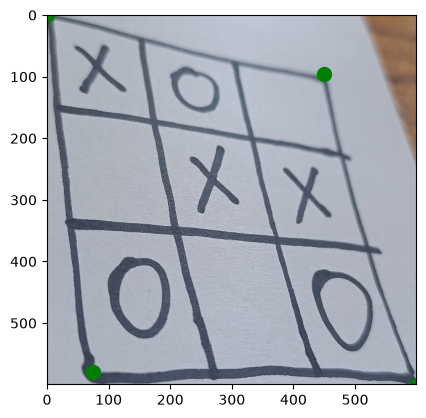

In [188]:
x_coords = [0, 450, 600, 75]
y_coords = [0, 95, 600, 580]

plt.plot(x_coords, y_coords, 'go', markersize=10)
plt.imshow(warped_grids["nobody wins"])

plt.show()

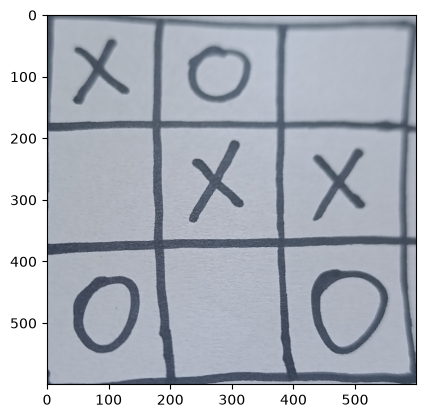

In [189]:
src_pts = np.array([[x_coords[0], y_coords[0]],
                    [x_coords[1], y_coords[1]],
                    [x_coords[2], y_coords[2]],
                    [x_coords[3], y_coords[3]]], dtype=np.float32)
width = 600
height = 600
dst_pts = np.float32([[0, 0],
                      [width, 0],
                      [width, height],
                      [0, height]])
matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped = cv2.warpPerspective(warped_grids["nobody wins"], matrix, (width, height))
warped_grids["nobody wins"] = warped
plt.imshow(warped_grids["nobody wins"])
plt.show()

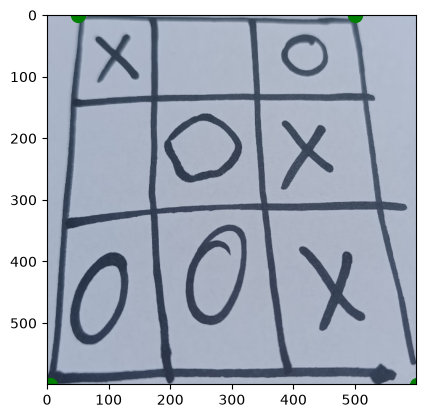

In [193]:
x_coords = [50, 500, 600, 5]
y_coords = [0, 0, 600, 600]

plt.plot(x_coords, y_coords, 'go', markersize=10)
plt.imshow(warped_grids["bad photo & circles wins"])

plt.show()

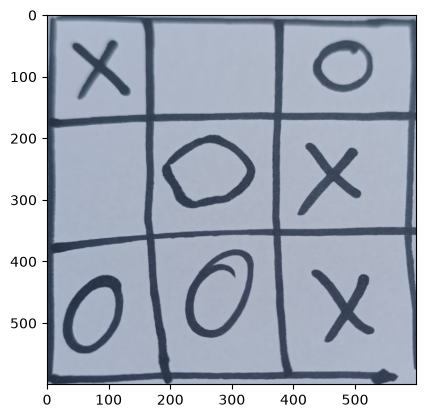

In [194]:
src_pts = np.array([[x_coords[0], y_coords[0]],
                    [x_coords[1], y_coords[1]],
                    [x_coords[2], y_coords[2]],
                    [x_coords[3], y_coords[3]]], dtype=np.float32)
width = 600
height = 600
dst_pts = np.float32([[0, 0],
                      [width, 0],
                      [width, height],
                      [0, height]])
matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped = cv2.warpPerspective(warped_grids["bad photo & circles wins"], matrix, (width, height))
warped_grids["bad photo & circles wins"] = warped
plt.imshow(warped_grids["bad photo & circles wins"])
plt.show()

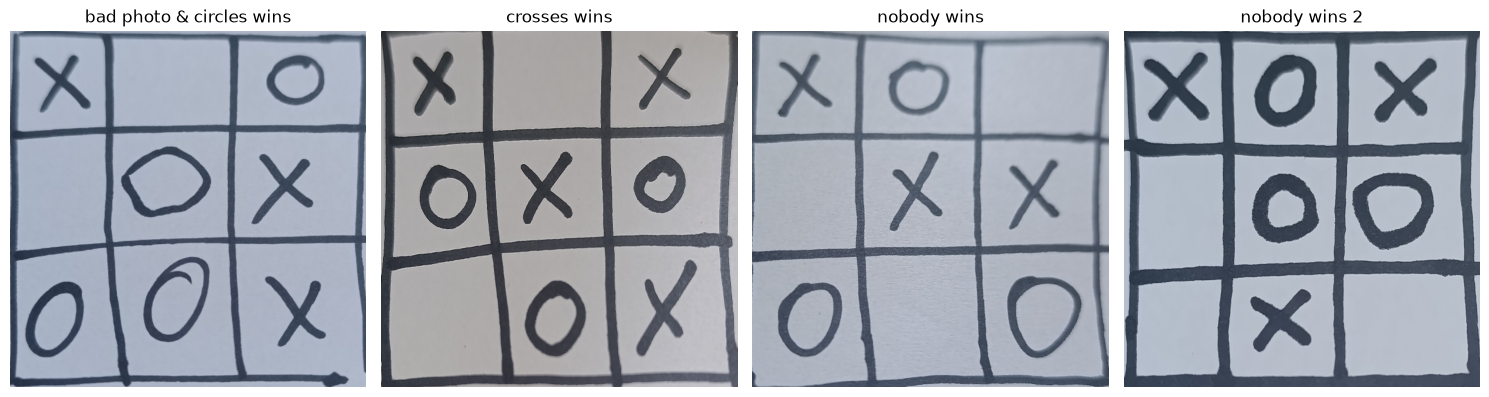

In [195]:
plot_images_in_row(list(warped_grids.values()), list(warped_grids.keys()))

<i> Виконання детекції ліній, щоб виконати поділ на сектори

In [ ]:
# TODO:
#  1. Дослідити як працює метод Хафа (детекція ліній)
#  2. Відібрати найбільші
#  3. Поділити сітку на сектори --->>> для лінії у разі виграшної комбінації, зберегти центри секторів
#  4. Додати маску навколо кожного сектору, або додати margin
#  5. Перевести у бінарне зображення
#  6. Canny Edge Detection для обʼєкта всередині: X / O / empty
#  7. Записати для кожного зображення: назва, матриця стану поля